### Preliminaries

In [1]:
!pip install rsome
!pip install mosek
!rm mosek.lic
!git clone https://github.com/erickdelage/80624
!cp ./80624/mosek.lic .
!rm -r ./80624
!mkdir -p /root/mosek
!cp ./mosek.lic /root/mosek
#!pip install -i https://pypi.gurobi.com gurobipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 734.2 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 36.3 MB/s eta 0:00:00
rm: cannot remove 'mosek.lic': No such file or directory
Cloning into '80624'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 27 (delta 6), reused 24 (delta 3), pack-reused 0
Receiving objects: 100% (27/27), 30.23 KiB | 3.02 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [2]:
import rsome as rso
import numpy as np
import pandas as pd
from rsome import ro
from rsome import msk_solver as my_solver  #Import Mosek solver interface
import matplotlib.pyplot as plt
#from rsome import grb_solver as my_solver  #Import Gurobi solver interface


In [3]:
from datetime import datetime, timedelta
# Get the current date
current_date = datetime.now().date()
# Format the date as a string
formatted_date = current_date.strftime('%d.%m.%Y')

In [4]:
# Declare function to save results to Excel for report
from openpyxl import load_workbook
from openpyxl import Workbook
from openpyxl.utils import get_column_letter

def flatten_list(nested_list):
    """Flatten a nested list."""
    flattened_list = []
    for sublist in nested_list:
        if isinstance(sublist, list):
            flattened_list.extend(flatten_list(sublist))
        else:
            flattened_list.append(sublist)
    return flattened_list

def save_list_to_excel(nested_list, file_path, sheet_name):

    # Flatten the nested list
    flattened_list = flatten_list(nested_list)

    # Load the existing workbook if it exists
    try:
        workbook = load_workbook(file_path)
    except FileNotFoundError:
        workbook = Workbook()

    # Check if the specified sheet exists in the workbook
    if sheet_name in workbook.sheetnames:
        # Get the existing sheet
        sheet = workbook[sheet_name]
        # Find the next available column
        next_column = len(list(sheet.columns)) + 1
    else:
        # Create a new sheet
        sheet = workbook.create_sheet(title=sheet_name)
        next_column = 1

    # Write data to the sheet
    for row_idx, item in enumerate(flattened_list, start=1):
        sheet.cell(row=row_idx, column=next_column, value=item)

    # Save the workbook back to the file
    workbook.save(file_path)

### Load the data


In [5]:
# LOAD DATA

def read_excel_file(file_path):
    # Read the Excel file and return a dictionary of DataFrames for each sheet
    xls = pd.ExcelFile(file_path)
    sheet_dict = {sheet_name: pd.read_excel(xls, sheet_name, skiprows=[1]) for sheet_name in xls.sheet_names}
    return sheet_dict

#file_path = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Robust Optimization/Project_database_v2.xlsx'
file_path = 'Project_database.xlsx'

data = read_excel_file(file_path)

In [6]:
# Declare constants and parameters
n = 10 #number of items (co-substrates)
m = 20 #number of suppliers

Vr = 2*1350+3179 #m3
N = 365 #purchase horizon (days)...depends on Availability data aggregation
p_ch4 = 110 #fixed biomethane price
p_ch4 = 110 *0.01035 #Conversion MWh/Nm3CH4

bnds = np.array([[0, 120], #VS
        [0.2, 4], #TKN
        [20, 40], #C/N
        [0, 4], #TAN
        [5, 15], #TAC
        [0, 10], #LI
        [0, 10], #TVFA
        [20,50] #HRT
       ])

In [7]:
# Redeclare parameters needed to create the BMP time-curve
k_hydr = data['Item characteristics'].values[:,13].astype('float64')
k_hyds = data['Item characteristics'].values[:,14].astype('float64')
BMPinf_r = data['Item characteristics'].values[:,15].astype('float64')
BMPinf_s = data['Item characteristics'].values[:,16].astype('float64')
itemtype = data['Item characteristics'].values[:,-1]

In [8]:
# Re-declaration of loaded data
A = data['Availability'].values[5:25,1:11].astype('float64')

k = np.concatenate(([data['Item characteristics'].values[:,3]], data['Item characteristics'].values[:,6:12].T), axis=0).T
k = k.astype('float64')

VS = data['Item characteristics']['VS'].values.astype('float64')
BMPinf = data['Item characteristics']['BMPinf'].values.astype('float64')
Cp = data['Purchase prices'].values[5:25,1:11].astype('float64')

# Compute the matrix of transportation costs
Fixed_tariff = data['Item characteristics']['Fixed_tariff'].values.astype('float64')
d = data['Ct']['d'].values.astype('float64')
d = d.reshape(-1, 1)
matrix = np.tile(Fixed_tariff, (m, 1))
Ct = (matrix + d)/20

In [9]:
# SAMPLE BMP CURVE
# Declare functions to create the BMP time-curve for later sampling
from scipy.integrate import odeint

# Define the differential equations
def model(state, t, k1, k2):
    x, y, z = state
    dxdt = -k1 * x
    dydt = -k2 * y
    dzdt = k1 * x + k2 * y
    return [dxdt, dydt, dzdt]

def evaluate_model(x0,y0,k1,k2):

    # Initial conditions
    x0 = x0
    y0 = y0
    z0 = 0.0

    # Time points to solve the equations
    t = np.linspace(0, 50, 50)

    # Rate constants
    k1 = k1
    k2 = k2

    # Solve the differential equations
    state = odeint(model, [x0, y0, z0], t, args=(k1, k2))
    x_response = state[:, 0]
    y_response = state[:, 1]
    z_response = state[:, 2]

    return t,z_response
# --------------------------------------------------------------
bmp_curve = []
for k1,k2,x0,y0 in zip(k_hydr,k_hyds,BMPinf_r,BMPinf_s):
    t,z_response = evaluate_model(x0,y0,k1,k2)
    bmp_curve.append(z_response)

    # Calculate dz/dt using numerical differentiation
    dt = t[1] - t[0]
    dzdt_response = np.gradient(z_response, dt)

    # Plot the time response
    #fig, ax = plt.subplots(figsize=(12, 6))
    ##ax.plot(t, x_response, label='x(t)')
    ##ax.plot(t, y_response, label='y(t)')
    #ax.plot(t, z_response, label='z(t)', marker= 'o')
    #ax.plot(t, dzdt_response, label='dz/dt')
    #plt.xlabel('Time')
    #plt.ylabel('BMP(t)')
    #plt.legend()
    #plt.grid(True)
    #plt.show()
bmp_curve = np.array(bmp_curve, dtype=np.float64)
#print(bmp_curve)

### Deterministic problem

"First simplified approach" (BMP = BMP$_{inf}$, no HRT effect)

In [10]:
#Solve the nominal problem

# Find indices correspondent to a certain cluster to apply 'regulating authority constraints'
table1A = np.isin(itemtype,['S','B'])
table1B = np.isin(itemtype,['P'])
slurries = np.isin(itemtype,['S'])
secondharvest = np.isin(itemtype,['P2'])
Nminus1 = 1/N

#Create model
model=ro.Model('Biomethane supply-chain simplified')

#Define variables
x = model.dvar((n,m))          #

#List the objective and constraints
model.max(Nminus1*(p_ch4*(VS*BMPinf/1000)@x.sum(axis=1)-(Cp.T*x).sum()-(Ct.T*x).sum()))
model.st(x <= A.T)       # Availability constraint
for i in range(np.size(k,1)):
    model.st(k[:,i]@(x.sum(axis=1)) <= bnds[i][1]*x.sum()) # Technical constraint (max)
    model.st(k[:,i]@(x.sum(axis=1)) >= bnds[i][0]*x.sum()) # Technical constraint (min)
model.st(Vr*N <= bnds[7][1]*x.sum()) # HRT constraint (max)
model.st(Vr*N >= bnds[7][0]*x.sum()) # HRT constraint (min)
model.st(x >= 0)

# Add constraints from regulating autorithy
model.st(x[table1A].sum() >= 0.7*x.sum())
model.st(x[table1B].sum() <= 0.3*x.sum())
model.st(x[secondharvest].sum() <= 0.2*x.sum())
model.st(x[slurries].sum() >= 0.4*x.sum())

#Add constraint to consume substrate of 'myplant'
model.st(x.T[-1] == A[-1])

#Solve the model
model.solve(my_solver)
opt_obj = model.get()  #
opt_x = x.get()

print('The net revenue for the purchase horizon of interest is', round(opt_obj,2),
      'euro/day and the optimal fluxes of items to be purchased are', np.round(opt_x, decimals=2))

Being solved by Mosek...
Solution status: Optimal
Running time: 0.0174s
The net revenue for the purchase horizon of interest is 6906.56 euro/day and the optimal fluxes of items to be purchased are [[    0.       0.       0.       0.       0.    1376.63     0.       0.
      0.       0.     362.9      0.    1131.06  1454.71     0.       0.
      0.       0.       0.       0.  ]
 [    0.       0.       0.       0.       0.       0.       0.       0.
      0.       0.       0.       0.       0.       0.       0.       0.
      0.       0.       0.       0.  ]
 [    0.       0.       0.       0.       0.       0.       0.       0.
      0.       0.       0.       0.       0.       0.       0.       0.
      0.       0.       0.    1906.96]
 [    0.       0.       0.       0.       0.   76300.94     0.       0.
      0.       0.       0.       0.       0.       0.       0.       0.
      0.       0.       0.    3300.19]
 [13967.08     0.    3072.66     0.       0.       0.       0.       0.

In [11]:
# Compute quantities of interest with the obtained solution
x = opt_x
J = opt_obj
HRT = Vr*N/x.sum()
print(f'HRT is {HRT}')
f_obj = p_ch4*(VS*BMPinf/1000)@x.sum(axis=1)/N
f_obj2 = (Cp.T*x).sum()/N
f_obj3 = (Ct.T*x).sum()/N
print(f_obj)
print(f_obj2)
print(f_obj3)
print(f_obj-f_obj2-f_obj3)


#diet
diet = []
for i,name in zip(range(len(x)),data['Item characteristics'].values[:,0]):
    itempercentage = x[i].sum()/x.sum()*100
    print(f'{name} is {round(itempercentage,2)}% of the influent diet')
    diet.append(round(itempercentage,2))

# Save to Excel
results = [HRT, f_obj, f_obj2, f_obj3, J, diet]
file_path = 'Results.xlsx'
sheet_name = 'D-LP'
save_list_to_excel(results, file_path, sheet_name)

# Check which constraint is active
table1A = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['S','B'])]).sum()
table1B = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['P'])]).sum()
slurries = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['S'])]).sum()
secondharvest = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['P2'])]).sum()
deltarl = [table1A*100/x.sum() - 70, 30 - table1B*100/x.sum(), slurries*100/x.sum() - 40, 20 - secondharvest*100/x.sum()]
for i in range(len(deltarl)):
    active = [deltarl[i] if deltarl[i]<0 else 0]
    print(f'Autorithy constraint {i} not respected by {round(active[0],2)}')

#
for i in range(np.size(k,1)):
    deltamax = k[:,i]@(x.sum(axis=1))/x.sum() - bnds[i][1] # Technical constraint (max)
    deltamin = k[:,i]@(x.sum(axis=1))/x.sum() - bnds[i][0] # Technical constraint (min)
    print(f'Technical constriant {i} has margin to UB equal to {round(deltamax,2)}')
    print(f'Technical constriant {i} has margin to LB equal to {round(deltamin,2)}')
deltaHRTmax = Vr*N/x.sum() - bnds[7][1] # HRT constraint (max)
print(f'HRT constriant has margin to UB equal to {round(deltaHRTmax,2)}')
deltaHRTmin = Vr*N/x.sum() - bnds[7][0] # HRT constraint (min)
print(f'HRT constriant has margin to LB equal to {round(deltaHRTmin,2)}')

HRT is 20.000000000000007
11825.709472255598
4024.640837013967
894.505561581664
6906.563073659967
Barley silage is 4.03% of the influent diet
Chicken dung is 0.0% of the influent diet
Cow dung is 1.78% of the influent diet
Cow slurry is 74.19% of the influent diet
Maize silage is 20.0% of the influent diet
Pig slurry is 0.0% of the influent diet
Sorghum silage is 0.0% of the influent diet
Tomato peels is 0.0% of the influent diet
Triticale silage is 0.0% of the influent diet
Wheat byproducts is 0.0% of the influent diet
Autorithy constraint 0 not respected by 0
Autorithy constraint 1 not respected by 0
Autorithy constraint 2 not respected by 0
Autorithy constraint 3 not respected by -0.0
Technical constriant 0 has margin to UB equal to 0.0
Technical constriant 0 has margin to LB equal to 120.0
Technical constriant 1 has margin to UB equal to -0.33
Technical constriant 1 has margin to LB equal to 3.47
Technical constriant 2 has margin to UB equal to -13.9
Technical constriant 2 has marg

"More realistic approach" (with BMP = BMP(HRT))

In [12]:
#Solve the nominal problem + HRT optimization

# Find indices correspondent to a certain cluster to apply 'regulating authority constraints'
table1A = np.isin(itemtype,['S','B'])
table1B = np.isin(itemtype,['P'])
slurries = np.isin(itemtype,['S'])
secondharvest = np.isin(itemtype,['P2'])

#Extract value from 'bmp_curve' at the given HRT
HRT=20
HRTminus1 = 1/HRT
Nminus1 = 1/N
BMP = []
for i in range(len(data['Item characteristics'].values[:,0])):
    BMPsubstrate = bmp_curve[i][HRT-1]
    BMP.append(BMPsubstrate)
BMP = np.array(BMP)

#Create model
model=ro.Model('Biomethane supply-chain real')

#Define variables
x = model.dvar((n,m))          #

#List the objective and constraints
model.max(Nminus1*(p_ch4*(VS*BMP/1000)@x.sum(axis=1)-(Cp.T*x).sum()-(Ct.T*x).sum())) #How shall I reformulate the objective function?
#model.st(x <= A)       # Stock constraint
model.st(x <= A.T)       # Availability constraint
for i in range(np.size(k,1)):
    model.st(k[:,i]@(x.sum(axis=1)) <= bnds[i][1]*x.sum()) # Technical constraint (max)
    model.st(k[:,i]@(x.sum(axis=1)) >= bnds[i][0]*x.sum()) # Technical constraint (min)
model.st(Vr*N == HRT*x.sum()) # HRT hard constraint
model.st(x >= 0)

#Add constraint to consume substrate of 'myplant'
model.st(x.T[-1] == A[-1])

#Add constraint to limit output residual BMP in digestate (authority limit)
model.st((BMPinf-BMP)@(x.sum(axis=1)) <= (0.15*BMPinf)@(x.sum(axis=1)))

# Add constraints from regulating autorithy
model.st(x[table1A].sum() >= 0.7*x.sum())
model.st(x[table1B].sum() <= 0.3*x.sum())
model.st(x[secondharvest].sum() <= 0.2*x.sum())
model.st(x[slurries].sum() >= 0.4*x.sum())

#Solve the model
model.solve(my_solver)
opt_obj_real = model.get()  #
opt_x_real = x.get()

print('The net revenue for the purchase horizon of interest is', round(opt_obj_real,2),
      'euro/day and the optimal fluxes of items to be purchased are', np.round(opt_x_real, decimals=2))

Being solved by Mosek...
Solution status: Optimal
Running time: 0.0030s
The net revenue for the purchase horizon of interest is 6060.96 euro/day and the optimal fluxes of items to be purchased are [[0.000000e+00 0.000000e+00 4.113200e+02 0.000000e+00 0.000000e+00
  1.376630e+03 0.000000e+00 0.000000e+00 2.430900e+02 0.000000e+00
  1.002410e+03 0.000000e+00 1.131060e+03 1.454710e+03 0.000000e+00
  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00]
 [0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  4.383000e+01 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00]
 [0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 1.906960e+

In [13]:
# Compute quantities of interest with the obtained solution
x = opt_x_real
J = opt_obj_real
HRT = Vr*N/x.sum()
print(f'HRT is {HRT}')
f_obj = p_ch4*(VS*BMP/1000)@x.sum(axis=1)/N
f_obj2 = (Cp.T*x).sum()/N
f_obj3 = (Ct.T*x).sum()/N
print(f_obj)
print(f_obj2)
print(f_obj3)
print(f_obj-f_obj2-f_obj3)


#diet
diet = []
for i,name in zip(range(len(x)),data['Item characteristics'].values[:,0]):
    itempercentage = x[i].sum()/x.sum()*100
    print(f'{name} is {round(itempercentage,2)}% of the influent diet')
    diet.append(round(itempercentage,2))

# Save to Excel
results = [HRT, f_obj, f_obj2, f_obj3, J, diet]
file_path = 'Results.xlsx'
sheet_name = 'D-LP_real'
save_list_to_excel(results, file_path, sheet_name)

#
table1A = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['S','B'])]).sum()
table1B = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['P'])]).sum()
slurries = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['S'])]).sum()
secondharvest = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['P2'])]).sum()
deltarl = [table1A*100/x.sum() - 70, 30 - table1B*100/x.sum(), slurries*100/x.sum() - 40, 20 - secondharvest*100/x.sum()]
for i in range(len(deltarl)):
    active = [deltarl[i] if deltarl[i]<0 else 0]
    print(f'Autorithy constraint {i} not respected by {round(active[0],2)}')

#
for i in range(np.size(k,1)):
    deltamax = k[:,i]@(x.sum(axis=1))/x.sum() - bnds[i][1] # Technical constraint (max)
    deltamin = k[:,i]@(x.sum(axis=1))/x.sum() - bnds[i][0] # Technical constraint (min)
    print(f'Technical constriant {i} has margin to UB equal to {round(deltamax,2)}')
    print(f'Technical constriant {i} has margin to LB equal to {round(deltamin,2)}')
deltaHRTmax = Vr*N/x.sum() - bnds[7][1] # HRT constraint (max)
print(f'HRT constriant has margin to UB equal to {round(deltaHRTmax,2)}')
deltaHRTmin = Vr*N/x.sum() - bnds[7][0] # HRT constraint (min)
print(f'HRT constriant has margin to LB equal to {round(deltaHRTmin,2)}')

HRT is 20.0
11243.396163200163
4290.294975351398
892.1450029925613
6060.956184856204
Barley silage is 5.24% of the influent diet
Chicken dung is 0.04% of the influent diet
Cow dung is 1.78% of the influent diet
Cow slurry is 3.08% of the influent diet
Maize silage is 20.0% of the influent diet
Pig slurry is 65.11% of the influent diet
Sorghum silage is 0.0% of the influent diet
Tomato peels is 0.0% of the influent diet
Triticale silage is 4.76% of the influent diet
Wheat byproducts is 0.0% of the influent diet
Autorithy constraint 0 not respected by 0
Autorithy constraint 1 not respected by 0
Autorithy constraint 2 not respected by 0
Autorithy constraint 3 not respected by 0
Technical constriant 0 has margin to UB equal to 0.0
Technical constriant 0 has margin to LB equal to 120.0
Technical constriant 1 has margin to UB equal to -0.21
Technical constriant 1 has margin to LB equal to 3.59
Technical constriant 2 has margin to UB equal to -17.19
Technical constriant 2 has margin to LB equ

### Design of uncertainty sets

In [14]:
# Design of uncertainty set
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load mean, maximum and minimum
# Of prices
price_data = data['Purchase prices']
barley = price_data['Barley silage'].values.astype('float64')[0:3]
print(barley)
chicken = price_data['Chicken dung'].values.astype('float64')[0:3]
print(chicken)
cow_d = price_data['Cow dung'].values.astype('float64')[0:3]
print(cow_d)
cow_s = price_data['Cow slurry'].values.astype('float64')[0:3]
print(cow_s)
maize= price_data['Maize silage'].values.astype('float64')[0:3]
print(maize)
pig = price_data['Pig slurry'].values.astype('float64')[0:3]
print(pig)
sorghum = price_data['Sorghum silage'].values.astype('float64')[0:3]
print(sorghum)
tomato = price_data['Tomato peels'].values.astype('float64')[0:3]
print(tomato)
triticale= price_data['Triticale silage'].values.astype('float64')[0:3]
print(triticale)
wheat = price_data['Wheat byproducts'].values.astype('float64')[0:3]
print(wheat)

# Of availabilities
availability_data = data['Availability']
barley_a = availability_data['Barley silage'].values.astype('float64')[0:3]
print(barley_a)
chicken_a = availability_data['Chicken dung'].values.astype('float64')[0:3]
print(chicken_a)
cow_d_a = availability_data['Cow dung'].values.astype('float64')[0:3]
print(cow_d_a)
cow_s_a = availability_data['Cow slurry'].values.astype('float64')[0:3]
print(cow_s_a)
maize_a= availability_data['Maize silage'].values.astype('float64')[0:3]
print(maize_a)
pig_a = availability_data['Pig slurry'].values.astype('float64')[0:3]
print(pig_a)
sorghum_a = availability_data['Sorghum silage'].values.astype('float64')[0:3]
print(sorghum_a)
tomato_a = availability_data['Tomato peels'].values.astype('float64')[0:3]
print(tomato_a)
triticale_a = availability_data['Triticale silage'].values.astype('float64')[0:3]
print(triticale_a)
wheat_a = availability_data['Wheat byproducts'].values.astype('float64')[0:3]
print(wheat_a)
products_a = [barley_a,chicken_a,cow_d_a,cow_s_a,maize_a,pig_a,sorghum_a,tomato_a,triticale_a,wheat_a]

# Of BMP
bmp_data = [BMPinf,data['Item characteristics']['BMPinf Max'].values.astype('float64'),data['Item characteristics']['BMPinf Min'].values.astype('float64')]
print(bmp_data)

[34.  38.  17.5]
[40. 68. 23.]
[10.  11.   8.6]
[5.5  8.45 1.5 ]
[40.31333333 65.         31.5       ]
[4.4  7.1  2.62]
[27.   43.53 21.1 ]
[24.25 40.    8.5 ]
[32.  38.  19.3]
[153.36904762 284.          71.        ]
[7923.6        8555.55555556 7247.33333333]
[44295.33333333 46340.         42839.        ]
[2241448.66666667 2275979.         2208206.        ]
[3567740.33333333 3895625.         2957218.        ]
[164060.39565217 192286.95652174 148648.5       ]
[2352168.66666667 2388775.         2282678.        ]
[1255.43565 1483.916   1089.207  ]
[5784.256 6386.04  5096.   ]
[11568.512 12772.08  10192.   ]
[21160.041   27828.36875 17293.2375 ]
[array([308.79633333, 294.36180556, 182.1875    , 231.36      ,
       343.74585455, 202.32      , 280.4325    , 191.375     ,
       288.5       , 331.88416667]), array([323.989, 375.   , 209.   , 320.   , 400.   , 252.3  , 372.96 ,
       223.   , 351.   , 367.1  ]), array([286.2   , 185.7   , 165.    , 181.5   , 295.0644, 125.    ,
       152.

In [15]:
# Function to peak a random realization of price
def samples(vector):
  mean = vector[0]
  max = vector[1]
  min = vector[2]

  alpha = max-min
  beta = alpha*(max-min)/(mean-min)-alpha
  return (max-min)*np.random.beta(alpha,beta)+min

# Function to generate prices data for one year in an incremental way
def one_year(product,plot=False):
  min = product[2]
  max= product[1]
  price_year = np.zeros(52)
  price_year[0] = samples(product)
  for i in range(price_year.shape[0]-1):
    incremented= price_year[i]+np.random.triangular(-0.5,0,0.5)
    if incremented <=min:
      price_year[i+1] = min
    elif incremented >=max:
      price_year[i+1] = max
    else:
      price_year[i+1] = incremented

  if plot:
    plt.plot(np.arange(1,len(price_year)+1),price_year)
  return price_year

array([[7.90973119e+03, 7.94061473e+03, 7.93825334e+03, 7.92634146e+03,
        7.91722069e+03],
       [4.42996204e+04, 4.42932923e+04, 4.43058918e+04, 4.42907792e+04,
        4.43119953e+04],
       [2.24166822e+06, 2.24148165e+06, 2.24147784e+06, 2.24140045e+06,
        2.24152427e+06],
       [3.56729945e+06, 3.56805726e+06, 3.56787562e+06, 3.56777214e+06,
        3.56735659e+06],
       [1.64037319e+05, 1.64023687e+05, 1.64074270e+05, 1.64130396e+05,
        1.63960345e+05],
       [2.35207954e+06, 2.35232612e+06, 2.35239451e+06, 2.35236643e+06,
        2.35212097e+06],
       [1.25214049e+03, 1.24648261e+03, 1.25480730e+03, 1.26638360e+03,
        1.25000526e+03],
       [5.78410402e+03, 5.77935743e+03, 5.77645251e+03, 5.79475944e+03,
        5.77959200e+03],
       [1.15722725e+04, 1.15672824e+04, 1.15659944e+04, 1.15562851e+04,
        1.15542248e+04],
       [2.11307246e+04, 2.11710370e+04, 2.11758479e+04, 2.11292410e+04,
        2.11753856e+04]])

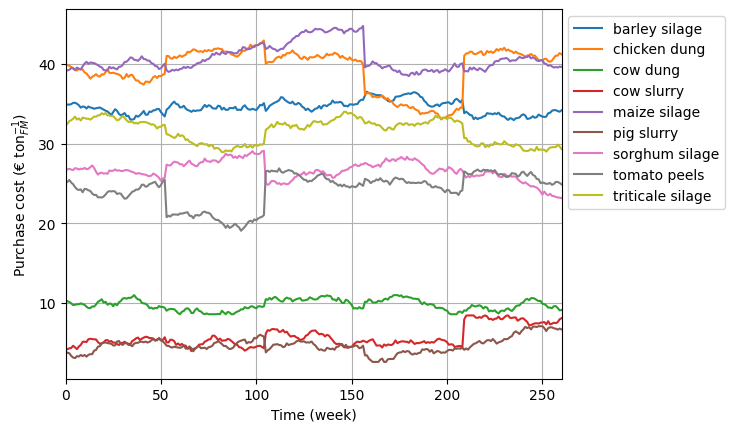

In [16]:
# Generation of data for prices
# 5 years with 52 realization/year (one/week)
np.random.seed(5)
product_prices_over_time=np.zeros([10,52*5])
for j in [0,52,52*2,52*3,52*4]:
  d=one_year(barley,False)
  product_prices_over_time[0,j:j+52]=d
plt.plot(np.arange(1,len(product_prices_over_time[0])+1),product_prices_over_time[0],label='barley silage')
for j in [0,52,52*2,52*3,52*4]:
  d=one_year(chicken,False)
  product_prices_over_time[1,j:j+52]=d
plt.plot(np.arange(1,len(product_prices_over_time[1])+1),product_prices_over_time[1],label='chicken dung')
for j in [0,52,52*2,52*3,52*4]:
  d=one_year(cow_d,False)
  product_prices_over_time[2,j:j+52]=d
plt.plot(np.arange(1,len(product_prices_over_time[2])+1),product_prices_over_time[2],label='cow dung')
for j in [0,52,52*2,52*3,52*4]:
  d=one_year(cow_s,False)
  product_prices_over_time[3,j:j+52]=d
plt.plot(np.arange(1,len(product_prices_over_time[3])+1),product_prices_over_time[3],label='cow slurry')
for j in [0,52,52*2,52*3,52*4]:
  d=one_year(maize,False)
  product_prices_over_time[4,j:j+52]=d
plt.plot(np.arange(1,len(product_prices_over_time[4])+1),product_prices_over_time[4],label='maize silage')
for j in [0,52,52*2,52*3,52*4]:
  d=one_year(pig,False)
  product_prices_over_time[5,j:j+52]=d
plt.plot(np.arange(1,len(product_prices_over_time[5])+1),product_prices_over_time[5],label='pig slurry')
for j in [0,52,52*2,52*3,52*4]:
  d=one_year(sorghum,False)
  product_prices_over_time[6,j:j+52]=d
plt.plot(np.arange(1,len(product_prices_over_time[6])+1),product_prices_over_time[6],label='sorghum silage')
for j in [0,52,52*2,52*3,52*4]:
  d=one_year(tomato,False)
  product_prices_over_time[7,j:j+52]=d
plt.plot(np.arange(1,len(product_prices_over_time[7])+1),product_prices_over_time[7],label='tomato peels')
for j in [0,52,52*2,52*3,52*4]:
  d=one_year(triticale,False)
  product_prices_over_time[8,j:j+52]=d
plt.plot(np.arange(1,len(product_prices_over_time[8])+1),product_prices_over_time[8],label='triticale silage')
for j in [0,52,52*2,52*3,52*4]:
  d=one_year(wheat,False)
  product_prices_over_time[9,j:j+52]=d
#plt.plot(np.arange(1,len(product_prices_over_time[9])+1),product_prices_over_time[9],label='wheat')
#filename = "wheat_price.csv"
#np.savetxt(filename, product_prices_over_time, delimiter=",")
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.xlabel('Time (week)')
plt.ylabel('Purchase cost (€ ton$_{FM}^{-1}$)')
plt.grid()
plt.xlim(0,260)

plt.savefig(f'Pricedata_{current_date}.png', bbox_inches='tight')

# Data generation of availability
# One realization for each year
product_availability_over_time=np.zeros([10,5])#
row=0
for i in products_a:
  for j in range(5):
    product_availability_over_time[row,j] = samples(i)
  row+=1
product_availability_over_time

In [18]:
# Design of uncertainty sets
# Budgeted sets

# Probability to meet chance constraint
Prob = 0.95
eps = 1-Prob

#Define Gamma_price
mu_price=np.mean(product_prices_over_time, axis=1)
tmp = product_prices_over_time - mu_price.reshape(-1,1)@np.ones((1,5*52))
tmp_max = abs(tmp).max(1)
Zs_price = np.diag(1/tmp_max)@tmp
P_price = np.diag(tmp_max)
tmp=np.sort(np.linalg.norm(Zs_price,1,axis=0))
Gamma_price=tmp[int(np.ceil((1-eps)*len(tmp)))-1]
print('Calibrating the budgeted set: Gamma_price={0:0.6f}'.format(Gamma_price))

#Defne Gamma_Availability
mu_avail=np.mean(product_availability_over_time, axis=1)
tmp = product_availability_over_time - mu_avail.reshape(-1,1)@np.ones((1,5))
tmp_max = abs(tmp).max(1)
Zs_avail = np.diag(1/tmp_max)@tmp
P_avail = np.diag(tmp_max)
tmp=np.sort(np.linalg.norm(Zs_avail,1,axis=0))
Gamma_availability=tmp[int(np.ceil((1-eps)*len(tmp)))-1]
print('Calibrating the budgeted set: Gamma_availability={0:0.6f}'.format(Gamma_availability))

#Define Gamma_BMP
# Calibrating the budgeted set based on theoretical result for symmetric [-1,1] distributions
Gamma_BMP = (2*n*np.log(1/eps))**0.5
print('Calibrating the budgeted set: Gamma_BMP={0:0.6f}'.format(Gamma_BMP))


Calibrating the budgeted set: Gamma_price=5.400348
Calibrating the budgeted set: Gamma_availability=7.155556
Calibrating the budgeted set: Gamma_BMP=7.740455


### Robust problem

In [19]:
# Check constraint formulation for availability peaking one realization from Zs
deterministic_mean_avail = [arr[0] for arr in products_a]
sellersizes = []
for i in range(n):
    column_a = A[:,i]/deterministic_mean_avail[i]
    sellersizes.append(column_a)
    #print(column_a.sum())
sellersizes = np.stack(sellersizes)
#print(sellersize[0])
#print(A[:,0])
Z = [arr[0] for arr in Zs_avail]
#print((mu_avail+P_avail@Z))
Anew = sellersizes.T*(mu_avail+P_avail@Z)
#print(Anew)

# Check constraint formulation for prices peaking one realization from Zs
item_presence = np.where(A != 0, 1, 0)
Z = [arr[0] for arr in Zs_price]
Cpnew = item_presence*(mu_price+P_price@Z)
#print(Cpnew[0])
#print(Cp[0])

# Compute maximum variation of BMP (toward direction of interest for robustification)
bmpdev = 1 - bmp_data[2]/bmp_data[0]
#print(bmpdev)

"First simplified approach" (BMP = BMP$_{inf}$, no HRT effect)

In [20]:
#Solve the robustified problem

# Find indices correspondent to a certain cluster to apply 'regulating authority constraints'
table1A = np.isin(itemtype,['S','B'])
table1B = np.isin(itemtype,['P'])
slurries = np.isin(itemtype,['S'])
secondharvest = np.isin(itemtype,['P2'])

# Which uncertainty is considered?
uncertain_bmp = False
uncertain_price = True

#Create model
model=ro.Model('Biomethane supply-chain robust simplified')

#Define variables
s = model.dvar(1) #Lower-bound for revenues
c = model.dvar(1) #Ubber-bound for costs
x = model.dvar((n,m)) #Decision variable
z = model.rvar(n) #Random variables = perturbation to availabilities
w = model.rvar(n) #Random variables = perturbation to prices
l = model.rvar(n) #Random variables = perturbation to BMP

#Define 'availability uncertainty set'
availabilitySet = (-1<=z, z<=1, rso.norm(z,1)<=Gamma_availability)
#Define 'prices uncertainty set'
pricesSet = (-1<=w, w<=1, rso.norm(w,1)<=Gamma_price)
#Define 'BMP uncertainty set'
BMPSet = (-1<=l, l<=1, rso.norm(l,1)<=Gamma_BMP)

#List the objective and constraints
model.max(s-c)
if uncertain_bmp == True:
  model.st((s <= Nminus1*(p_ch4*(VS*BMPinf*(1+bmpdev*l)*(1/1000))@x.sum(axis=1))).forall(BMPSet)) #uncomment to include BMP uncertainty
else:
  model.st(s <= Nminus1*(p_ch4*(VS*BMPinf*(1/1000))@x.sum(axis=1))) #comment to include BMP uncertainty
if uncertain_price == True:
  model.st((c >= Nminus1*(((item_presence*(mu_price+P_price@w)).T*x).sum() + (Ct.T*x).sum())).forall(pricesSet)) #uncomment to include price uncertainty
else:
  model.st(c >= Nminus1*((Cp.T*x).sum() + (Ct.T*x).sum())) #comment to include price uncertainty

model.st((x[:,0:-1] <= (sellersizes[:,0:-1].T*(mu_avail+P_avail@z)).T).forall(availabilitySet))       # Availability constraint

for i in range(np.size(k,1)):
    model.st(k[:,i]@(x.sum(axis=1)) <= bnds[i][1]*x.sum()) # Technical constraint (max)
    model.st(k[:,i]@(x.sum(axis=1)) >= bnds[i][0]*x.sum()) # Technical constraint (min)
model.st(Vr*N <= bnds[7][1]*x.sum()) # HRT constraint (max)
model.st(Vr*N >= bnds[7][0]*x.sum()) # HRT constraint (min)
model.st(x >= 0)

#Add constraint to consume substrate of 'myplant'
model.st((x.T[-1] == A[-1]))

# Add constraints from regulating autorithy
model.st(x[table1A].sum() >= 0.7*x.sum())
model.st(x[table1B].sum() <= 0.3*x.sum())
model.st(x[secondharvest].sum() <= 0.2*x.sum())
model.st(x[slurries].sum() >= 0.4*x.sum())

#Solve the model
model.solve(my_solver)
opt_obj_robust = model.get()  #
opt_x_robust = x.get()
opt_s = s.get()
opt_c = c.get()

print('The net revenue for the purchase horizon of interest is', round(opt_obj_robust,2),
      'euro/day and the optimal fluxes of items to be purchased are', np.round(opt_x_robust, decimals=2))

Being solved by Mosek...
Solution status: Optimal
Running time: 0.1769s
The net revenue for the purchase horizon of interest is 5966.98 euro/day and the optimal fluxes of items to be purchased are [[    0.       0.       0.       0.       0.    1374.22     0.       0.
      0.       0.     369.83     0.    1129.08  1452.17     0.       0.
      0.       0.       0.       0.  ]
 [    0.       0.       0.       0.       0.       0.       0.       0.
      0.       0.       0.       0.       0.       0.       0.       0.
      0.       0.       0.       0.  ]
 [    0.       0.       0.       0.       0.       0.       0.       0.
      0.       0.       0.       0.       0.       0.       0.       0.
      0.       0.       0.    1906.96]
 [    0.       0.       0.       0.       0.   76300.94     0.       0.
      0.       0.       0.       0.       0.       0.       0.       0.
      0.       0.       0.    3300.19]
 [13958.54     0.    3083.52     0.       0.       0.       0.       0.

In [21]:
# Compute quantities of interest with the obtained solution
x = opt_x_robust
s = opt_s
c = opt_c
J = opt_obj_robust
HRT = Vr*N/x.sum()
print(f'HRT is {HRT}')
f_obj = s[0]
f_obj3 = (Ct.T*x).sum()/N
f_obj2 = c[0] - f_obj3
print(f_obj)
print(f_obj2)
print(f_obj3)
print(f_obj-f_obj2-f_obj3)


#diet
diet = []
for i,name in zip(range(len(x)),data['Item characteristics'].values[:,0]):
    itempercentage = x[i].sum()/x.sum()*100
    print(f'{name} is {round(itempercentage,2)}% of the influent diet')
    diet.append(round(itempercentage,2))

# Save to Excel
results = [Gamma_availability, Gamma_price, Gamma_BMP, HRT, f_obj, f_obj2, f_obj3, J, diet, uncertain_bmp, uncertain_price]
file_path = 'Results.xlsx'
sheet_name = 'R-LP'
save_list_to_excel(results, file_path, sheet_name)

#
table1A = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['S','B'])]).sum()
table1B = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['P'])]).sum()
slurries = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['S'])]).sum()
secondharvest = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['P2'])]).sum()
deltarl = [table1A*100/x.sum() - 70, 30 - table1B*100/x.sum(), slurries*100/x.sum() - 40, 20 - secondharvest*100/x.sum()]
for i in range(len(deltarl)):
    active = [deltarl[i] if deltarl[i]<0 else 0]
    print(f'Autorithy constraint {i} not respected by {round(active[0],2)}')

#
for i in range(np.size(k,1)):
    deltamax = k[:,i]@(x.sum(axis=1))/x.sum() - bnds[i][1] # Technical constraint (max)
    deltamin = k[:,i]@(x.sum(axis=1))/x.sum() - bnds[i][0] # Technical constraint (min)
    print(f'Technical constriant {i} has margin to UB equal to {round(deltamax,2)}')
    print(f'Technical constriant {i} has margin to LB equal to {round(deltamin,2)}')
deltaHRTmax = Vr*N/x.sum() - bnds[7][1] # HRT constraint (max)
print(f'HRT constriant has margin to UB equal to {round(deltaHRTmax,2)}')
deltaHRTmin = Vr*N/x.sum() - bnds[7][0] # HRT constraint (min)
print(f'HRT constriant has margin to LB equal to {round(deltaHRTmin,2)}')

HRT is 20.000000000000007
11825.709472255596
4964.204591597474
894.5240004026949
5966.980880255427
Barley silage is 4.03% of the influent diet
Chicken dung is 0.0% of the influent diet
Cow dung is 1.78% of the influent diet
Cow slurry is 74.19% of the influent diet
Maize silage is 20.0% of the influent diet
Pig slurry is 0.0% of the influent diet
Sorghum silage is 0.0% of the influent diet
Tomato peels is 0.0% of the influent diet
Triticale silage is 0.0% of the influent diet
Wheat byproducts is 0.0% of the influent diet
Autorithy constraint 0 not respected by 0
Autorithy constraint 1 not respected by 0
Autorithy constraint 2 not respected by 0
Autorithy constraint 3 not respected by 0
Technical constriant 0 has margin to UB equal to 0.0
Technical constriant 0 has margin to LB equal to 120.0
Technical constriant 1 has margin to UB equal to -0.33
Technical constriant 1 has margin to LB equal to 3.47
Technical constriant 2 has margin to UB equal to -13.9
Technical constriant 2 has margin

"More realistic approach" (with BMP = BMP(HRT))

In [22]:
#Solve the robustified problem

# Find indices correspondent to a certain cluster to apply 'regulating authority constraints'
table1A = np.isin(itemtype,['S','B'])
table1B = np.isin(itemtype,['P'])
slurries = np.isin(itemtype,['S'])
secondharvest = np.isin(itemtype,['P2'])

#Extract value from 'bmp_curve' at the given HRT
HRT=20
HRTminus1 = 1/HRT
BMP = []
for i in range(len(data['Item characteristics'].values[:,0])):
    BMPsubstrate = bmp_curve[i][HRT-1]
    BMP.append(BMPsubstrate)

# Which uncertainty is considered?
uncertain_bmp = True
uncertain_price = True

# Which Gamma is considered
#deltaGamma = 0.1
#Gamma_availability = Gamma_availability*(1+deltaGamma)
#Gamma_price = 0.0
#Gamma_BMP = Gamma_BMP*(1+deltaGamma)

#Create model
model=ro.Model('Biomethane supply-chain robust real')

#Define variables
s = model.dvar(1) #Lower-bound for revenues
c = model.dvar(1) #Ubber-bound for costs
x = model.dvar((n,m)) #Decision variable
z = model.rvar(n) #Random variables = perturbation to availabilities
w = model.rvar(n) #Random variables = perturbation to prices
l = model.rvar(n) #Random variables = perturbation to BMP

#Define 'availability uncertainty set'
availabilitySet = (-1<=z, z<=1, rso.norm(z,1)<=Gamma_availability)
#Define 'prices uncertainty set'
pricesSet = (-1<=w, w<=1, rso.norm(w,1)<=Gamma_price)
#Define 'BMP uncertainty set'
BMPSet = (-1<=l, l<=1, rso.norm(l,1)<=Gamma_BMP)

#List the objective and constraints
model.max(s-c)
if uncertain_bmp == True:
  model.st((s <= Nminus1*(p_ch4*(VS*BMP*(1+bmpdev*l)*(1/1000))@x.sum(axis=1))).forall(BMPSet)) #uncomment to include BMP uncertainty
else:
  model.st(s <= Nminus1*(p_ch4*(VS*BMP*(1/1000))@x.sum(axis=1))) #comment to include BMP uncertainty
if uncertain_price == True:
  model.st((c >= Nminus1*(((item_presence*(mu_price+P_price@w)).T*x).sum() + (Ct.T*x).sum())).forall(pricesSet)) #uncomment to include price uncertainty
else:
  model.st(c >= Nminus1*((Cp.T*x).sum() + (Ct.T*x).sum())) #comment to include price uncertainty

model.st((x[:,0:-1] <= (sellersizes[:,0:-1].T*(mu_avail+P_avail@z)).T).forall(availabilitySet))       # Availability constraint

for i in range(np.size(k,1)):
    model.st(k[:,i]@(x.sum(axis=1)) <= bnds[i][1]*x.sum()) # Technical constraint (max)
    model.st(k[:,i]@(x.sum(axis=1)) >= bnds[i][0]*x.sum()) # Technical constraint (min)
model.st(Vr*N == HRT*x.sum()) # HRT hard constraint
model.st(x >= 0)

#Add constraint to consume substrate of 'myplant'
model.st((x.T[-1] == A[-1]))

#Add constraint to limit output residual BMP in digestate (authority limit)
model.st((((BMPinf-BMP)*(1+bmpdev*l))@(x.sum(axis=1)) <= (0.15*BMPinf*(1+bmpdev*l))@(x.sum(axis=1))).forall(BMPSet))

# Add constraints from regulating autorithy
model.st(x[table1A].sum() >= 0.7*x.sum())
model.st(x[table1B].sum() <= 0.3*x.sum())
model.st(x[secondharvest].sum() <= 0.2*x.sum())
model.st(x[slurries].sum() >= 0.4*x.sum())

#Solve the model
model.solve(my_solver)
opt_obj_robust_real = model.get()  #
opt_x_robust_real = x.get()
opt_s_real = s.get()
opt_c_real = c.get()

print('The net revenue for the purchase horizon of interest is', round(opt_obj_robust_real,2),
      'euro/day and the optimal fluxes of items to be purchased are', np.round(opt_x_robust_real, decimals=2))

Being solved by Mosek...
Solution status: Optimal
Running time: 0.1332s
The net revenue for the purchase horizon of interest is 3361.03 euro/day and the optimal fluxes of items to be purchased are [[    0.     421.62   410.6      0.     332.43  1374.22     0.       0.
   1370.57   418.4   1000.66     0.    1129.08  1452.17     0.       0.
      0.       0.       0.       0.  ]
 [    0.       0.       0.       0.       0.       0.       0.       0.
      0.       0.       0.       0.       0.       0.       0.       0.
      0.       0.       0.       0.  ]
 [    0.       0.       0.       0.       0.     357.12     0.       0.
      0.       0.       0.       0.       0.       0.       0.       0.
      0.       0.       0.    1906.96]
 [    0.       0.       0.       0.       0.     319.67     0.       0.
      0.       0.       0.       0.       0.       0.       0.       0.
      0.       0.       0.    3300.19]
 [13958.54     0.    3083.52     0.       0.       0.       0.       0.

In [23]:
# Compute quantities of interest with the obtained solution
x = opt_x_robust_real
s = opt_s_real
c = opt_c_real
J = opt_obj_robust_real
HRT = Vr*N/x.sum()
print(f'HRT is {HRT}')
f_obj = s[0]
f_obj3 = (Ct.T*x).sum()/N
f_obj2 = c[0] - f_obj3
print(f_obj)
print(f_obj2)
print(f_obj3)
print(f_obj-f_obj2-f_obj3)


#diet
diet = []
for i,name in zip(range(len(x)),data['Item characteristics'].values[:,0]):
    itempercentage = x[i].sum()/x.sum()*100
    print(f'{name} is {round(itempercentage,2)}% of the influent diet')
    diet.append(round(itempercentage,2))

# Save to Excel
results = [Gamma_availability, Gamma_price, Gamma_BMP, HRT, f_obj, f_obj2, f_obj3, J, diet, uncertain_bmp, uncertain_price]
file_path = 'Results.xlsx'
sheet_name = 'R-LP_real'
save_list_to_excel(results, file_path, sheet_name)

#
table1A = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['S','B'])]).sum()
table1B = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['P'])]).sum()
slurries = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['S'])]).sum()
secondharvest = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['P2'])]).sum()
deltarl = [table1A*100/x.sum() - 70, 30 - table1B*100/x.sum(), slurries*100/x.sum() - 40, 20 - secondharvest*100/x.sum()]
for i in range(len(deltarl)):
    active = [deltarl[i] if deltarl[i]<0 else 0]
    print(f'Autorithy constraint {i} not respected by {round(active[0],2)}')

#
for i in range(np.size(k,1)):
    deltamax = k[:,i]@(x.sum(axis=1))/x.sum() - bnds[i][1] # Technical constraint (max)
    deltamin = k[:,i]@(x.sum(axis=1))/x.sum() - bnds[i][0] # Technical constraint (min)
    print(f'Technical constriant {i} has margin to UB equal to {round(deltamax,2)}')
    print(f'Technical constriant {i} has margin to LB equal to {round(deltamin,2)}')
deltaHRTmax = Vr*N/x.sum() - bnds[7][1] # HRT constraint (max)
print(f'HRT constriant has margin to UB equal to {round(deltaHRTmax,2)}')
deltaHRTmin = Vr*N/x.sum() - bnds[7][0] # HRT constraint (min)
print(f'HRT constriant has margin to LB equal to {round(deltaHRTmin,2)}')

HRT is 20.000000000000004
9440.65986113749
5180.626975062132
899.0021021203529
3361.030783955005
Barley silage is 7.37% of the influent diet
Chicken dung is 0.0% of the influent diet
Cow dung is 2.11% of the influent diet
Cow slurry is 3.37% of the influent diet
Maize silage is 20.0% of the influent diet
Pig slurry is 64.52% of the influent diet
Sorghum silage is 0.0% of the influent diet
Tomato peels is 0.0% of the influent diet
Triticale silage is 2.63% of the influent diet
Wheat byproducts is 0.0% of the influent diet
Autorithy constraint 0 not respected by 0
Autorithy constraint 1 not respected by -0.0
Autorithy constraint 2 not respected by 0
Autorithy constraint 3 not respected by -0.0
Technical constriant 0 has margin to UB equal to -0.0
Technical constriant 0 has margin to LB equal to 120.0
Technical constriant 1 has margin to UB equal to -0.0
Technical constriant 1 has margin to LB equal to 3.8
Technical constriant 2 has margin to UB equal to -17.12
Technical constriant 2 has 

### Testing

In [24]:
# Generation of data for prices
# 1 years with 52 realization/year (one/week)
np.random.seed(5)
product_prices_test= []
d=np.array([samples(barley) for _ in range(20)])
product_prices_test.append(d)
d=np.array([samples(chicken) for _ in range(20)])
product_prices_test.append(d)
d=np.array([samples(cow_d) for _ in range(20)])
product_prices_test.append(d)
d=np.array([samples(cow_s) for _ in range(20)])
product_prices_test.append(d)
d=np.array([samples(maize) for _ in range(20)])
product_prices_test.append(d)
d=np.array([samples(pig) for _ in range(20)])
product_prices_test.append(d)
d=np.array([samples(sorghum) for _ in range(20)])
product_prices_test.append(d)
d=np.array([samples(tomato) for _ in range(20)])
product_prices_test.append(d)
d=np.array([samples(triticale) for _ in range(20)])
product_prices_test.append(d)
d=np.array([samples(wheat) for _ in range(20)])
product_prices_test.append(d)

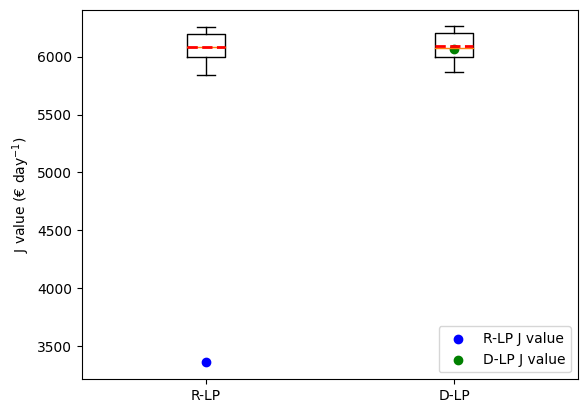

In [41]:
#At a given HRT...

def testJ(x,Cp):
    J = Nminus1*(p_ch4*(VS*BMP/1000)@x.sum(axis=1)-(Cp.T*x).sum()-(Ct.T*x).sum())
    return J

Cp_test_set = [item_presence*np.array(product_prices_test)[:,i] for i in range(20)]
J_test_robust_real = [testJ(opt_x_robust_real,Cp_test_set[i]) for i in range(20)]
J_test_deterministic_real = [testJ(opt_x_real,Cp_test_set[i]) for i in range(20)]

#----------------------------------------------------------------------------------------

# Plot the boxplot
plt.boxplot(J_test_robust_real, vert=True, positions=[1], meanline=True, showmeans=True, meanprops={'color': 'r', 'linewidth': 2})
plt.scatter([1], opt_obj_robust_real, color='b', label='R-LP J value')  # Highlight other value

plt.boxplot(J_test_deterministic_real, positions=[2], vert=True, meanline=True, showmeans=True, meanprops={'color': 'r', 'linewidth': 2})
plt.scatter([2], opt_obj_real, color='green', label='D-LP J value')  # Highlight other value

# Set labels and legend
plt.xticks([1, 2], ['R-LP', 'D-LP'])
plt.ylabel('J value (€ day$^{-1}$)')
plt.legend()

plt.savefig(f'Testing_{HRT}_{current_date}.png')

plt.show()

### Plot

<ipython-input-44-57cbda93c684>:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


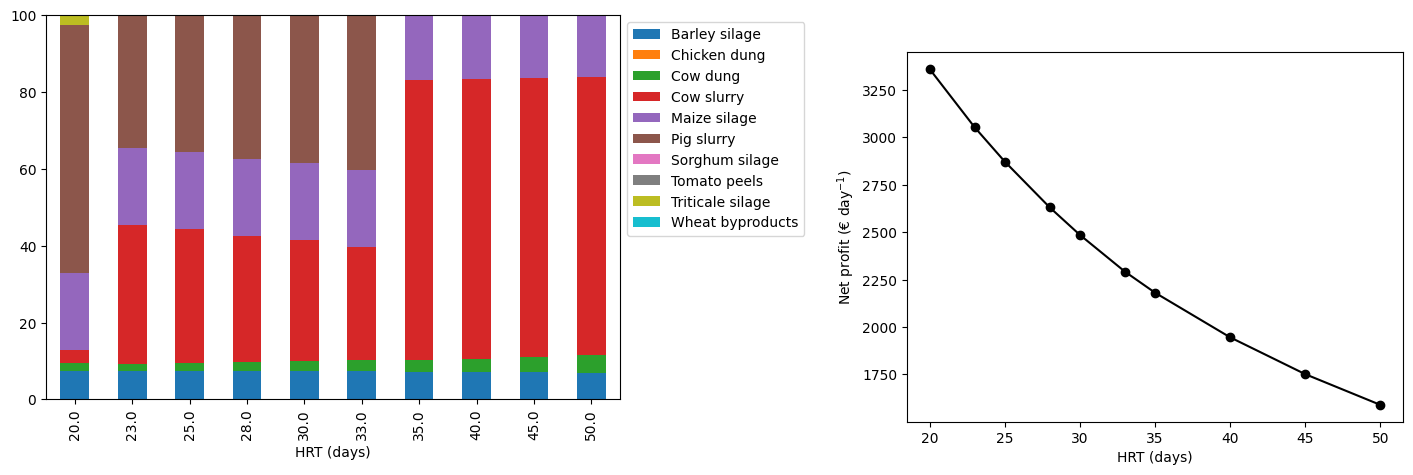

In [44]:
# Plot results
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Read the Excel file and select the desired sheet
dataforplot = pd.read_excel('Results.xlsx', sheet_name='R-LP_real (2)')

# Filter rows
filtered_df = dataforplot.iloc[6:,:]

# Step 2: Select specific columns and rows
x_values = filtered_df['HRT']  # Select values from the first row, excluding the first column
y_values = filtered_df['J'] # Select values from the second row, excluding the first column

bar_columns = filtered_df.columns[8:18]
other_data = filtered_df[filtered_df.columns[8:18]]

# Create subplots with a single row and one column
fig, ax1 = plt.subplots()

# Plot the stacked bar chart
other_data.plot(kind='bar', stacked=True, ax=ax1)
ax1.set_ylim(0,100)
ax1.set_xlabel('HRT (days)')

ax1.set_xticklabels(round(x_values,2))

# Get the position and size of the first subplot
pos1 = ax1.get_position()

# Define the position and size of the new axes object
pos2 = [pos1.x0 + 1.3, pos1.y0, pos1.width, pos1.height]

# Create a new axes object within the same figure
ax2 = fig.add_axes(pos2)

# Plot the line chart
ax2.plot(x_values, y_values, marker='o', color='black')
ax2.set_xlabel('HRT (days)')
ax2.set_ylabel('Net profit (€ day$^{-1}$)')

# Adjust layout to prevent overlap
plt.tight_layout()

# Move the legend outside the left subplot
ax1.legend(bbox_to_anchor=(1, 1), loc='upper left')

plt.savefig(f'Screening_HRT_R-LP_{current_date}.png', bbox_inches='tight')

# Show plots
plt.show()

<ipython-input-45-b9d076314715>:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


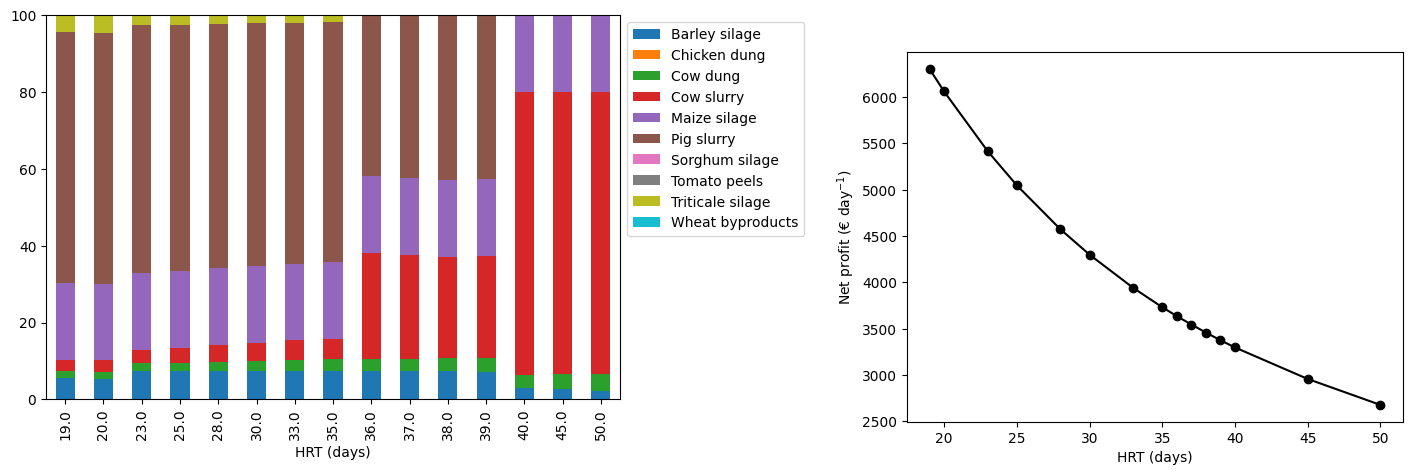

In [45]:
# Step 1: Read the Excel file and select the desired sheet
dataforplot = pd.read_excel('Results.xlsx', sheet_name='D-LP_real (2)')

# Filter rows
filtered_df = dataforplot.iloc[:,:]

# Step 2: Select specific columns and rows
x_values = filtered_df['HRT']  # Select values from the first row, excluding the first column
y_values = filtered_df['J'] # Select values from the second row, excluding the first column

# Sort the data based on x_values
sorted_indices = sorted(range(len(x_values)), key=lambda k: x_values.values[k])
x_values_sorted = [x_values.values[i] for i in sorted_indices]
y_values_sorted = [y_values.values[i] for i in sorted_indices]

bar_columns = filtered_df.columns[8:18]
other_data = filtered_df[filtered_df.columns[8:18]]

# Create subplots with a single row and one column
fig, ax1 = plt.subplots()

# Plot the stacked bar chart
other_data= other_data.iloc[sorted_indices]
other_data.plot(kind='bar', stacked=True, ax=ax1)
ax1.set_ylim(0,100)
ax1.set_xlabel('HRT (days)')

rounded_values = list(map(lambda x: round(x, 2), x_values_sorted))
ax1.set_xticklabels(rounded_values)

# Get the position and size of the first subplot
pos1 = ax1.get_position()

# Define the position and size of the new axes object
pos2 = [pos1.x0 + 1.3, pos1.y0, pos1.width, pos1.height]

# Create a new axes object within the same figure
ax2 = fig.add_axes(pos2)

# Plot the line chart
ax2.plot(x_values_sorted, y_values_sorted, marker='o', color='black')
ax2.set_xlabel('HRT (days)')
ax2.set_ylabel('Net profit (€ day$^{-1}$)')

# Adjust layout to prevent overlap
plt.tight_layout()

# Move the legend outside the left subplot
ax1.legend(bbox_to_anchor=(1, 1), loc='upper left')

plt.savefig(f'Screening_HRT_D-LP_{current_date}.png', bbox_inches='tight')

# Show plots
plt.show()

<ipython-input-46-4582aeca8bbd>:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


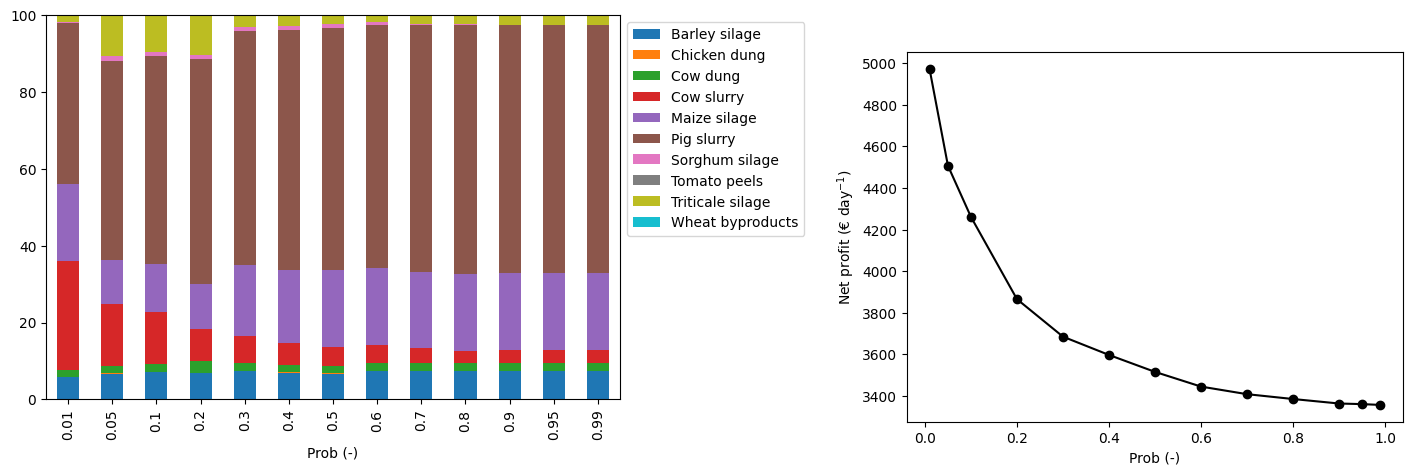

In [46]:
# Step 1: Read the Excel file and select the desired sheet
dataforplot = pd.read_excel('Results.xlsx', sheet_name='R-LP_real (3)')

# Filter rows
filtered_df = dataforplot.iloc[0:13,:] #!!!

# Step 2: Select specific columns and rows
x_values = filtered_df['VaR']  # Select values from the first row, excluding the first column
y_values = filtered_df['J'] # Select values from the second row, excluding the first column

# Sort the data based on x_values
sorted_indices = sorted(range(len(x_values)), key=lambda k: x_values.values[k])
x_values_sorted = [x_values.values[i] for i in sorted_indices]
y_values_sorted = [y_values.values[i] for i in sorted_indices]

bar_columns = filtered_df.columns[8:18]
other_data = filtered_df[filtered_df.columns[8:18]]

# Create subplots with a single row and one column
fig, ax1 = plt.subplots()

# Plot the stacked bar chart
other_data= other_data.iloc[sorted_indices]
other_data.plot(kind='bar', stacked=True, ax=ax1)
ax1.set_ylim(0,100)
ax1.set_xlabel('Prob (-)')

rounded_values = list(map(lambda x: round(x, 2), x_values_sorted))
ax1.set_xticklabels(rounded_values)

# Get the position and size of the first subplot
pos1 = ax1.get_position()

# Define the position and size of the new axes object
pos2 = [pos1.x0 + 1.3, pos1.y0, pos1.width, pos1.height]

# Create a new axes object within the same figure
ax2 = fig.add_axes(pos2)

# Plot the line chart
ax2.plot(x_values_sorted, y_values_sorted, marker='o', color='black')
ax2.set_xlabel('Prob (-)')
ax2.set_ylabel('Net profit (€ day$^{-1}$)')

# Adjust layout to prevent overlap
plt.tight_layout()

# Move the legend outside the left subplot
ax1.legend(bbox_to_anchor=(1, 1), loc='upper left')

plt.savefig(f'Screening_Prob_R-LP_20_{current_date}.png', bbox_inches='tight')

# Show plots
plt.show()

<ipython-input-52-d3e66193178d>:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


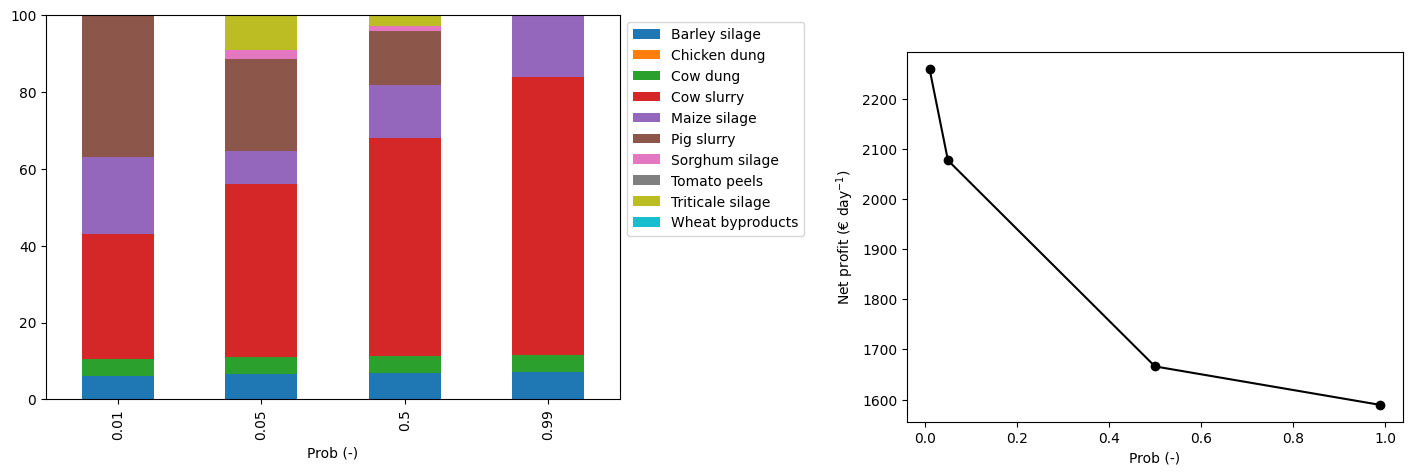

In [52]:
# Step 1: Read the Excel file and select the desired sheet
dataforplot = pd.read_excel('Results.xlsx', sheet_name='R-LP_real (3)')

# Filter rows
filtered_df = dataforplot.iloc[13:,:]

# Step 2: Select specific columns and rows
x_values = filtered_df['VaR']  # Select values from the first row, excluding the first column
y_values = filtered_df['J'] # Select values from the second row, excluding the first column

# Sort the data based on x_values
sorted_indices = sorted(range(len(x_values)), key=lambda k: x_values.values[k])
x_values_sorted = [x_values.values[i] for i in sorted_indices]
y_values_sorted = [y_values.values[i] for i in sorted_indices]

bar_columns = filtered_df.columns[8:18]
other_data = filtered_df[filtered_df.columns[8:18]]

# Create subplots with a single row and one column
fig, ax1 = plt.subplots()

# Plot the stacked bar chart
other_data= other_data.iloc[sorted_indices]
other_data.plot(kind='bar', stacked=True, ax=ax1)
ax1.set_ylim(0,100)
ax1.set_xlabel('Prob (-)')

rounded_values = list(map(lambda x: round(x, 2), x_values_sorted))
ax1.set_xticklabels(rounded_values)

# Get the position and size of the first subplot
pos1 = ax1.get_position()

# Define the position and size of the new axes object
pos2 = [pos1.x0 + 1.3, pos1.y0, pos1.width, pos1.height]  # Move the new axes to the right by 0.5

# Create a new axes object within the same figure
ax2 = fig.add_axes(pos2)

# Plot the line chart
ax2.plot(x_values_sorted, y_values_sorted, marker='o', color='black')
ax2.set_xlabel('Prob (-)')
ax2.set_ylabel('Net profit (€ day$^{-1}$)')

# Adjust layout to prevent overlap
plt.tight_layout()

# Move the legend outside the left subplot
ax1.legend(bbox_to_anchor=(1, 1), loc='upper left')

plt.savefig(f'Screening_Prob_R-LP_50_{current_date}.png', bbox_inches='tight')

# Show plots
plt.show()

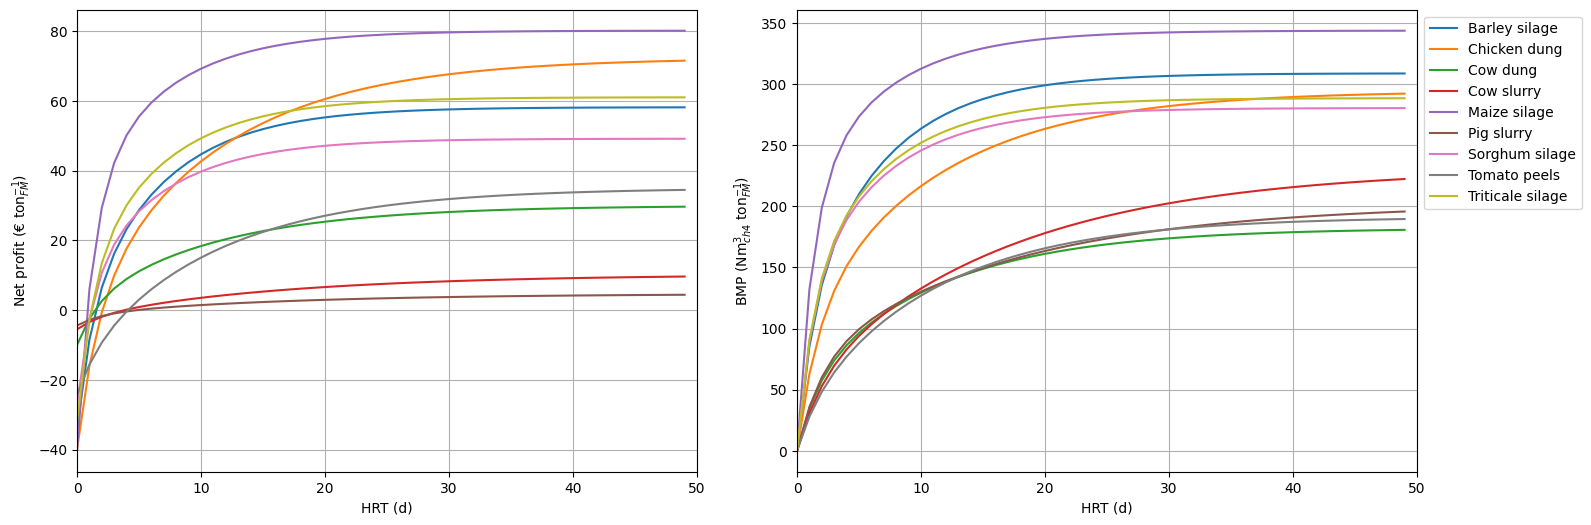

In [48]:
fig, ax1 = plt.subplots(figsize=(8,6))
# Get the position and size of the first subplot
pos1 = ax1.get_position()

# Define the position and size of the new axes object
pos2 = [pos1.x0 + 0.9, pos1.y0, pos1.width, pos1.height]  # Move the new axes to the right by 0.5

# Create a new axes object within the same figure
ax2 = fig.add_axes(pos2)

for i in range(n-1):
  ax1.plot(1.138*VS[i]*bmp_curve[i]/1000-data['Purchase prices'].values[0,1:11].astype('float64')[i],label=data['Item characteristics'].values[:,0][i])
  ax1.set_xlabel('HRT (d)')
  ax1.set_xlim(0,50)
  ax1.set_ylabel('Net profit (€ ton$_{FM}^{-1}$)')
  ax1.grid()

  ax2.plot(bmp_curve[i],label=data['Item characteristics'].values[:,0][i])
  ax2.set_xlabel('HRT (d)')
  ax2.set_xlim(0,50)
  ax2.set_ylabel('BMP (Nm$^3_{ch4}$ ton$_{FM}^{-1}$)')
  ax2.legend(bbox_to_anchor=(1, 1), loc='upper left')
  ax2.grid()

plt.savefig(f'NetProfitBMP_{current_date}.png', bbox_inches='tight')

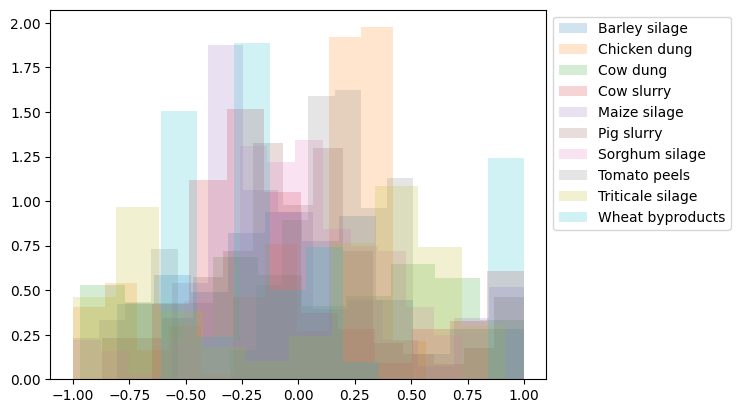

In [49]:
# Real distribution of price data (standardized to Zs)
fig, ax = plt.subplots(1, 1)
for i in np.arange(10):
    ax.hist(Zs_price[i,:], density=True, bins='auto', histtype='stepfilled', alpha=0.2, label = data['Item characteristics'].values[:,0][i])
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.savefig(f'Distribution_price_{current_date}.png', bbox_inches='tight')

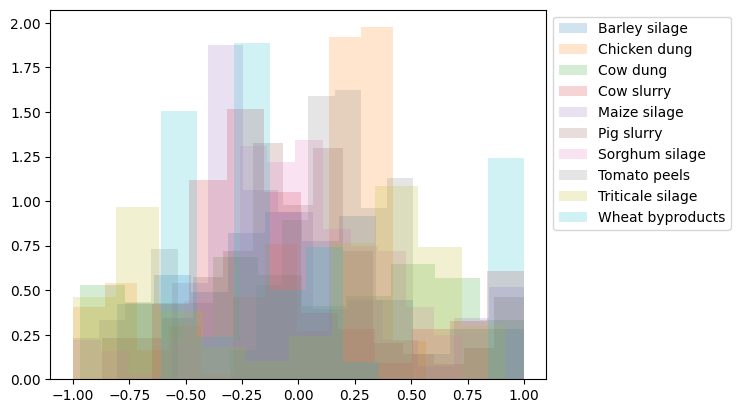

In [50]:
# Real distribution of price data (standardized to Zs)
# Distribution with 10 years realizations (Gamma_price(1%) was lower and Gamma_price(95%) was higher with respect to above-mentioned 5 years realizations)
fig, ax = plt.subplots(1, 1)
for i in np.arange(10):
    ax.hist(Zs_price[i,:], density=True, bins='auto', histtype='stepfilled', alpha=0.2, label = data['Item characteristics'].values[:,0][i])
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
#plt.savefig(f'Distribution_price_{current_date}.png', bbox_inches='tight')